<a href="https://colab.research.google.com/github/lovkush7/MACHINE-LEARNING-/blob/main/churned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = "/content/drive/MyDrive/dirty_customer_ml_dataset_5150_rows.csv"

In [4]:
import pandas as pd
data = pd.read_csv(path)

In [5]:
data.head()

,customer_id,age,gender,city,education,employment_status,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year,join_date,phone,email,churned
0,CUST_00001,41.0,Female,Kathmandu,SEE,Self-employed,104902.90,11.6,2.9,14158.95,7.0,2018-01-01,9897927116,customer1@example.com,No
1,CUST_00002,33.0,Female,Biratnagar,High School,Self Employed,29779.82,13.2,5.8,11691.22,8.0,2018-01-02,9864481067,customer2@example.com,No
2,CUST_00003,43.0,Male,Hetauda,Master,Employed,0.00,24.2,3.6,6126.37,5.0,2018-01-03,9855339410,customer3@example.com,No
3,CUST_00004,53.0,Male,Bhaktapur,PhD,Unemployed,108698.43,27.2,7.2,6144.84,4.0,2018-01-04,9876128481,customer4@example.com,yes
4,CUST_00005,32.0,NaN,Chitwan,Master,Employed,94495.41,4.9,3.5,11211.18,6.0,2018-01-05,9847472648,customer5@example.com,No


In [6]:
data.shape

(5150, 15)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5150 non-null   object 
 1   age                 5047 non-null   float64
 2   gender              4333 non-null   object 
 3   city                5150 non-null   object 
 4   education           4653 non-null   object 
 5   employment_status   4792 non-null   object 
 6   annual_income       5047 non-null   float64
 7   years_experience    5049 non-null   float64
 8   satisfaction_score  5047 non-null   float64
 9   purchase_amount     5047 non-null   float64
 10  orders_last_year    5150 non-null   float64
 11  join_date           5122 non-null   object 
 12  phone               5126 non-null   object 
 13  email               5117 non-null   object 
 14  churned             4921 non-null   object 
dtypes: float64(6), object(9)
memory usage: 603.6+ KB


In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [9]:
data.describe()

,age,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year
count,5047.000000,5.047000e+03,5049.000000,5047.000000,5047.000000,5150.000000
mean,37.236576,8.357557e+04,15.044365,6.656093,15412.180925,8.512816
std,43.185021,3.914251e+05,41.354144,4.522600,51478.662872,9.967754
min,-10.000000,-5.000000e+03,-40.400000,-5.000000,-1000.000000,-5.000000
25%,27.000000,3.054446e+04,4.100000,5.200000,6169.210000,6.000000
50%,35.000000,4.968407e+04,12.700000,6.500000,10411.290000,8.000000
75%,43.000000,8.077664e+04,21.800000,7.700000,16159.270000,10.000000
max,999.000000,9.999999e+06,983.700000,99.000000,1000000.000000,250.000000


In [10]:
data.duplicated().sum()

np.int64(150)

In [11]:
data[data.duplicated(keep=False)]

,customer_id,age,gender,city,education,employment_status,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year,join_date,phone,email,churned
4,CUST_00005,32.0,NaN,Chitwan,Master,Employed,94495.41,4.9,3.5,11211.18,6.0,2018-01-05,9847472648,customer5@example.com,No
78,CUST_00079,36.0,NaN,Kathmandu,bachelor,Unemployed,24352.85,11.4,3.9,10848.30,7.0,2018-03-20,9887153533,customer79@example.com,No
145,CUST_00146,44.0,Female,Biratnagar,High School,Self-employed,91472.55,20.0,9.9,18568.26,7.0,2018-05-26,9890150410,customer146@example.com,Y
161,CUST_00162,44.0,Female,Kathmandu,Bachelor,employed,210768.83,24.9,5.8,14322.61,5.0,2018-06-11,9846559249,customer162@example.com,N
172,CUST_00173,34.0,M,Biratnagar,High School,Student,72029.53,13.5,8.7,5815.15,6.0,2018-06-22,9828697853,customer173@example.com,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5145,CUST_00447,39.0,Male,Butwal,High School,Employed,206097.70,24.8,8.2,4117.14,3.0,2019-03-23,9819733710,customer447@example.com,No
5146,CUST_00173,34.0,M,Biratnagar,High School,Student,72029.53,13.5,8.7,5815.15,6.0,2018-06-22,9828697853,customer173@example.com,No
5147,CUST_04286,37.0,NaN,Hetauda,bachelor,Student,166100.97,11.9,9.2,10547.78,10.0,2029-09-25,9842900773,customer4286@example.com,No
5148,CUST_03817,30.0,Female,Lalitpur,NaN,Student,38086.37,9.4,6.0,17410.75,12.0,2028-06-13,9820425161,customer3817@example.com,Yes


In [12]:
data.drop_duplicates(inplace=True)

In [13]:
num_cols = data.select_dtypes(include="number").columns

data[num_cols] = data[num_cols].fillna(
    data[num_cols].median()
)

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
data.isnull().sum()

,0
customer_id,0
age,0
gender,793
city,0
education,480
employment_status,347
annual_income,0
years_experience,0
satisfaction_score,0
purchase_amount,0


In [16]:
data[data['gender'].isnull()]

,customer_id,age,gender,city,education,employment_status,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year,join_date,phone,email,churned
4,CUST_00005,32.0,NaN,Chitwan,Master,Employed,94495.41,4.9,3.5,11211.18,6.0,2018-01-05,9847472648,customer5@example.com,No
16,CUST_00017,23.0,NaN,Nepalgunj,Bachelor,Employed,38144.61,10.8,7.1,5753.09,9.0,2018-01-17,9850224226,customer17@example.com,No
22,CUST_00023,36.0,NaN,Lalitpur,SEE,employed,32783.75,18.7,6.4,13644.52,11.0,2018-01-23,9840683925,customer23@example.com,Yes
23,CUST_00024,18.0,NaN,Butwal,Master,Unemployed,64456.72,-10.9,5.9,8338.70,8.0,2018-01-24,9832366791,customer24@example.com,Yes
24,CUST_00025,28.0,NaN,Kathmandu,Bachelors,Self-employed,148369.01,14.7,4.2,15739.70,11.0,2021-99-99,9825012842,customer25@example.com,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4974,CUST_04975,17.0,NaN,Nepalgunj,NaN,Employed,63271.21,-12.1,9.1,4289.56,6.0,2031-08-15,9886926034,customer4975@example.com,No
4979,CUST_04980,8.0,NaN,Chitwan,Bachelors,Student,12484.74,-7.0,9.6,14311.34,11.0,2031-08-20,9861876830,customer4980@example.com,No
4980,CUST_04981,21.0,NaN,Nepalgunj,Bachelor,Unemployed,19620.00,3.9,4.7,7164.43,3.0,2031-08-21,9897908531,customer4981@example.com,No
4983,CUST_04984,33.0,NaN,Biratnagar,SEE,Self-employed,33185.95,12.8,6.0,9088.48,3.0,2031-08-24,9849059994,customer4984@example.com,No


In [17]:
cat_cols = data.select_dtypes(include="object").columns

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [18]:
num_cols = data.select_dtypes(include="number").columns
for col in num_cols:
  data[col] = data[col].fillna(data[col].mode()[0])

In [19]:
data.isnull().sum()

,0
customer_id,0
age,0
gender,0
city,0
education,0
employment_status,0
annual_income,0
years_experience,0
satisfaction_score,0
purchase_amount,0


In [20]:
data.head()

,customer_id,age,gender,city,education,employment_status,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year,join_date,phone,email,churned
0,CUST_00001,41.0,Female,Kathmandu,SEE,Self-employed,104902.90,11.6,2.9,14158.95,7.0,2018-01-01,9897927116,customer1@example.com,No
1,CUST_00002,33.0,Female,Biratnagar,High School,Self Employed,29779.82,13.2,5.8,11691.22,8.0,2018-01-02,9864481067,customer2@example.com,No
2,CUST_00003,43.0,Male,Hetauda,Master,Employed,0.00,24.2,3.6,6126.37,5.0,2018-01-03,9855339410,customer3@example.com,No
3,CUST_00004,53.0,Male,Bhaktapur,PhD,Unemployed,108698.43,27.2,7.2,6144.84,4.0,2018-01-04,9876128481,customer4@example.com,yes
4,CUST_00005,32.0,Male,Chitwan,Master,Employed,94495.41,4.9,3.5,11211.18,6.0,2018-01-05,9847472648,customer5@example.com,No


In [21]:
data['gender'].value_counts(dropna=False)

,count
gender,
Male,2224
Female,1302
M,506
female,429
F,358
Other,181


In [22]:
data['gender'] = data['gender'].replace(
    {
        "M":"Male",
        "F":"Female",
        "female":"Female"
    }
)

In [23]:
data['gender'].value_counts(dropna=False)

,count
gender,
Male,2730
Female,2089
Other,181


In [24]:
data['gender'] = data['gender'].str.lower()

In [25]:
data['gender'].value_counts(dropna=False)

,count
gender,
male,2730
female,2089
other,181


In [26]:
data['employment_status'].value_counts(dropna=False)

,count
employment_status,
Employed,2329
Self-employed,864
Student,569
Unemployed,507
Self Employed,377
employed,354


In [27]:
data['employment_status']= data['employment_status'].replace({
    "self employed":"self-employed"
}).str.lower()

In [28]:
data['employment_status'].value_counts(dropna=False)

,count
employment_status,
employed,2683
self-employed,864
student,569
unemployed,507
self employed,377


In [29]:
data['churned'].value_counts(dropna=False)

,count
churned,
No,2376
Yes,1309
NO,418
N,337
yes,312
Y,248


In [30]:
data['churned']= data['churned'].replace({
    "N":"no",
    "Y":"yes"
}).str.lower()

In [31]:
data['churned'].value_counts(dropna=False)

,count
churned,
no,3131
yes,1869


In [32]:
data['city'].value_counts()

,count
city,
Chitwan,532
Bhaktapur,527
Butwal,521
Dharan,516
Kathmandu,506
Biratnagar,502
Nepalgunj,489
Pokhara,488
Lalitpur,463


In [33]:
data['city'] = data['city'].str.lower()

In [34]:
data['education'].value_counts()

,count
education,
Bachelor,1868
Master,729
High School,687
SEE,598
Bachelors,530
bachelor,448
PhD,140


In [35]:
data['education'] = data['education'].str.lower()

In [36]:
data.head()

,customer_id,age,gender,city,education,employment_status,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year,join_date,phone,email,churned
0,CUST_00001,41.0,female,kathmandu,see,self-employed,104902.90,11.6,2.9,14158.95,7.0,2018-01-01,9897927116,customer1@example.com,no
1,CUST_00002,33.0,female,biratnagar,high school,self employed,29779.82,13.2,5.8,11691.22,8.0,2018-01-02,9864481067,customer2@example.com,no
2,CUST_00003,43.0,male,hetauda,master,employed,0.00,24.2,3.6,6126.37,5.0,2018-01-03,9855339410,customer3@example.com,no
3,CUST_00004,53.0,male,bhaktapur,phd,unemployed,108698.43,27.2,7.2,6144.84,4.0,2018-01-04,9876128481,customer4@example.com,yes
4,CUST_00005,32.0,male,chitwan,master,employed,94495.41,4.9,3.5,11211.18,6.0,2018-01-05,9847472648,customer5@example.com,no


In [37]:
data.describe()

,age,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000
mean,37.107200,8.296016e+04,14.931660,6.661440,15403.828506,8.528000
std,41.155321,3.916861e+05,39.202033,4.531738,51701.231945,10.102575
min,-10.000000,-5.000000e+03,-40.400000,-5.000000,-1000.000000,-5.000000
25%,27.000000,3.100266e+04,4.400000,5.300000,6311.407500,6.000000
50%,35.000000,4.957700e+04,12.800000,6.500000,10404.510000,8.000000
75%,43.000000,7.985287e+04,21.600000,7.700000,16013.502500,10.000000
max,999.000000,9.999999e+06,983.700000,99.000000,1000000.000000,250.000000


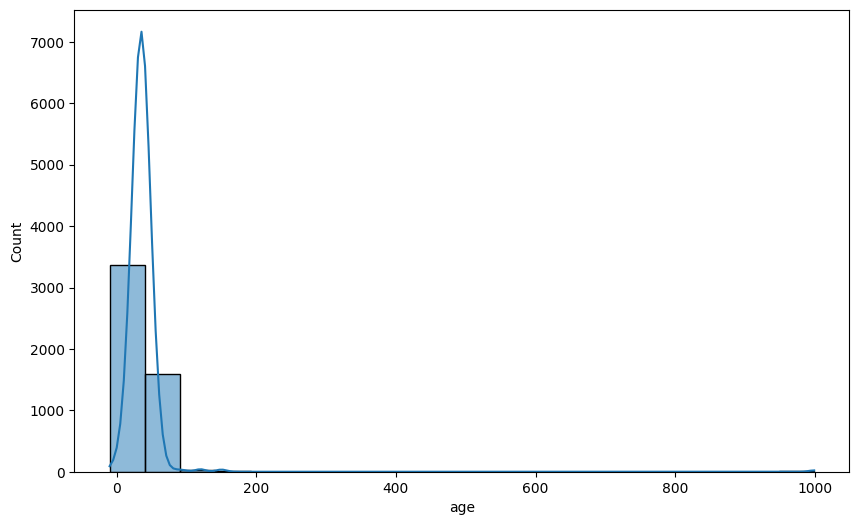

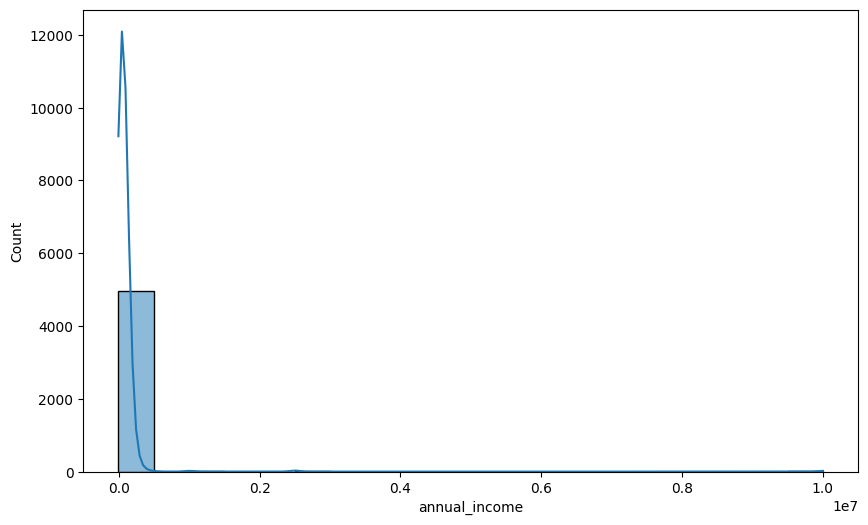

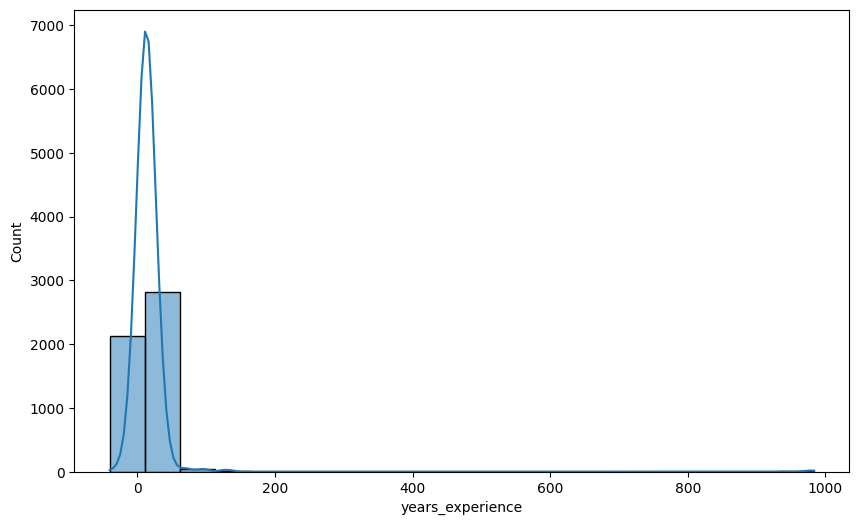

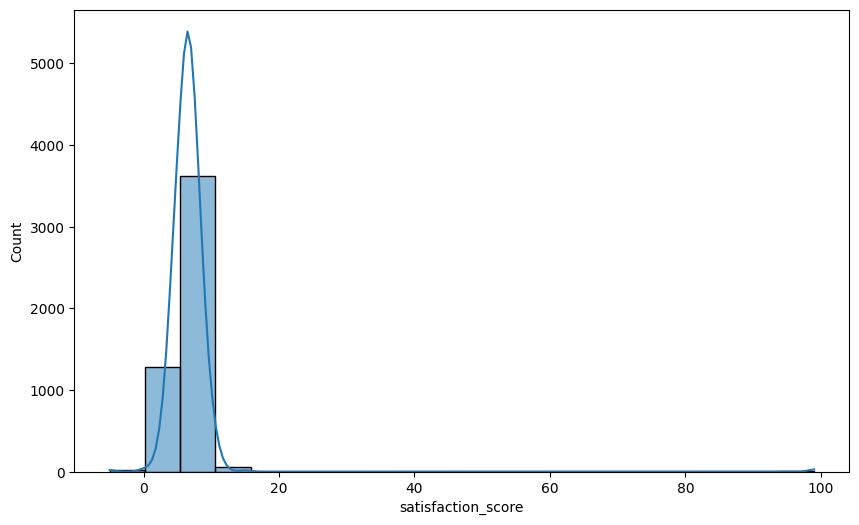

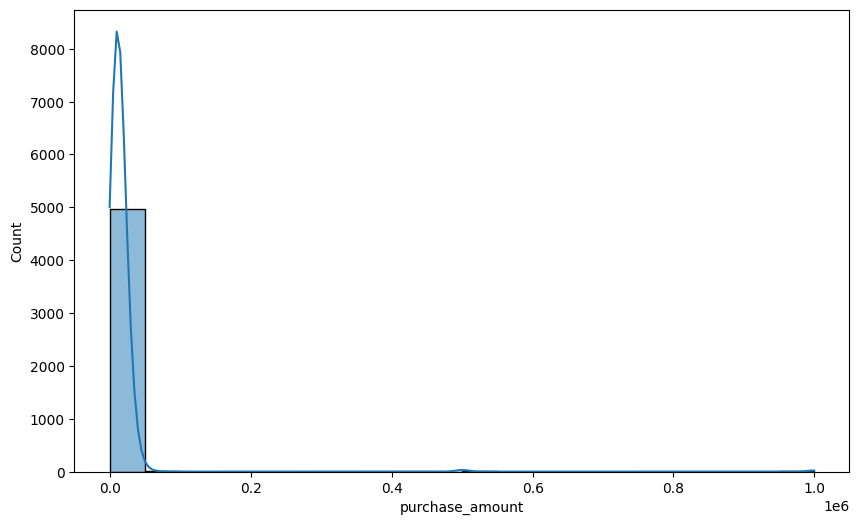

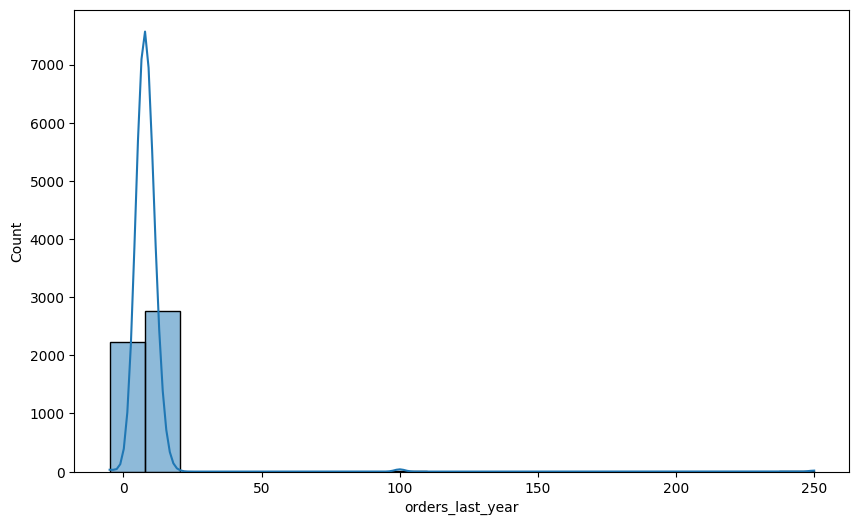

In [38]:
for col in num_cols:
  plt.figure(figsize=(10,6))
  sns.histplot(data[col],kde=True, bins=20)

In [39]:
for col in num_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower) |
        (data[col] > upper)
    ]

    print(col)
    print("Lower:", lower)
    print("Upper:", upper)
    print("Outliers:", len(outliers))
    print()

age
Lower: 3.0
Upper: 67.0
Outliers: 107

annual_income
Lower: -42272.65874999999
Upper: 153128.19124999997
Outliers: 306

years_experience
Lower: -21.400000000000006
Upper: 47.400000000000006
Outliers: 111

satisfaction_score
Lower: 1.6999999999999993
Upper: 11.3
Outliers: 59

purchase_amount
Lower: -8241.735000000002
Upper: 30566.645000000004
Outliers: 193

orders_last_year
Lower: 0.0
Upper: 16.0
Outliers: 47



In [40]:
data[(data['age'] > 92) | (data['age'] < 3)][['age']]

,age
168,120.0
176,-10.0
250,95.0
262,-4.0
286,95.0
...,...
4779,-3.0
4928,150.0
4929,150.0
4944,0.0


In [41]:
data.loc[(data['age'] > 92) | (data['age'] < 3), 'age'] = np.nan

In [42]:
data[data['age'].isna()][['age']]


,age
168,NaN
176,NaN
250,NaN
262,NaN
286,NaN
...,...
4779,NaN
4928,NaN
4929,NaN
4944,NaN


In [43]:
data[(data['age'] > 92) | (data['age'] < 3)][['age']]

,age


In [44]:
data['age'] = data['age'].fillna(data['age'].median())

In [45]:
data[data['age'].isna()][['age']]

,age


In [46]:
data[(data['annual_income'] > 153128.19124999997) | (data['annual_income'] < 0)][['annual_income']]

,annual_income
35,184952.62
57,281050.81
62,198065.64
65,230214.26
75,195785.55
...,...
4903,190018.06
4937,158912.62
4948,2500000.00
4952,223290.24


In [47]:
data.describe()

,age,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000
mean,35.218600,8.296016e+04,14.931660,6.661440,15403.828506,8.528000
std,11.724483,3.916861e+05,39.202033,4.531738,51701.231945,10.102575
min,3.000000,-5.000000e+03,-40.400000,-5.000000,-1000.000000,-5.000000
25%,28.000000,3.100266e+04,4.400000,5.300000,6311.407500,6.000000
50%,35.000000,4.957700e+04,12.800000,6.500000,10404.510000,8.000000
75%,43.000000,7.985287e+04,21.600000,7.700000,16013.502500,10.000000
max,85.000000,9.999999e+06,983.700000,99.000000,1000000.000000,250.000000


In [48]:
data.loc[data["years_experience"] < 0, "years_experience"] = np.nan

In [49]:
Q1 = data["years_experience"].quantile(0.25)
Q3 = data["years_experience"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data.loc[
    (data["years_experience"] < lower) |
    (data["years_experience"] > upper),
    "years_experience"
] = np.nan

In [50]:
data.loc[data['annual_income'] < 0, "annual_income"] = np.nan

In [51]:
Q1 = data["annual_income"].quantile(0.25)
Q3 = data["annual_income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data.loc[
    (data["annual_income"] < lower) |
    (data["annual_income"] > upper),
    "annual_income"
] = np.nan

In [52]:
Q1 = data["satisfaction_score"].quantile(0.25)
Q3 = data["satisfaction_score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data.loc[
    (data["satisfaction_score"] < lower) |
    (data["satisfaction_score"] > upper),
    "satisfaction_score"
] = np.nan

In [53]:
data.loc[data['purchase_amount'] < 0, "purchase_amount"] = np.nan

In [54]:
Q1 = data["purchase_amount"].quantile(0.25)
Q3 = data["purchase_amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data.loc[
    (data["purchase_amount"] < lower) |
    (data["purchase_amount"] > upper),
    "purchase_amount"
] = np.nan

In [55]:
Q1 = data["orders_last_year"].quantile(0.25)
Q3 = data["orders_last_year"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data.loc[
    (data["orders_last_year"] < lower) |
    (data["orders_last_year"] > upper),
    "orders_last_year"
] = np.nan

In [56]:
data.describe()

,age,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year
count,5000.000000,4683.000000,4135.000000,4941.000000,4792.000000,4953.000000
mean,35.218600,54120.546472,16.209940,6.490771,11229.491565,7.976984
std,11.724483,31453.032156,9.836635,1.724906,6593.400229,2.781320
min,3.000000,0.000000,-0.000000,1.700000,0.000000,0.000000
25%,28.000000,29554.530000,8.600000,5.300000,6127.147500,6.000000
50%,35.000000,47637.960000,15.000000,6.500000,10247.545000,8.000000
75%,43.000000,71662.225000,22.700000,7.600000,15150.002500,10.000000
max,85.000000,152297.490000,45.000000,11.300000,30565.460000,16.000000


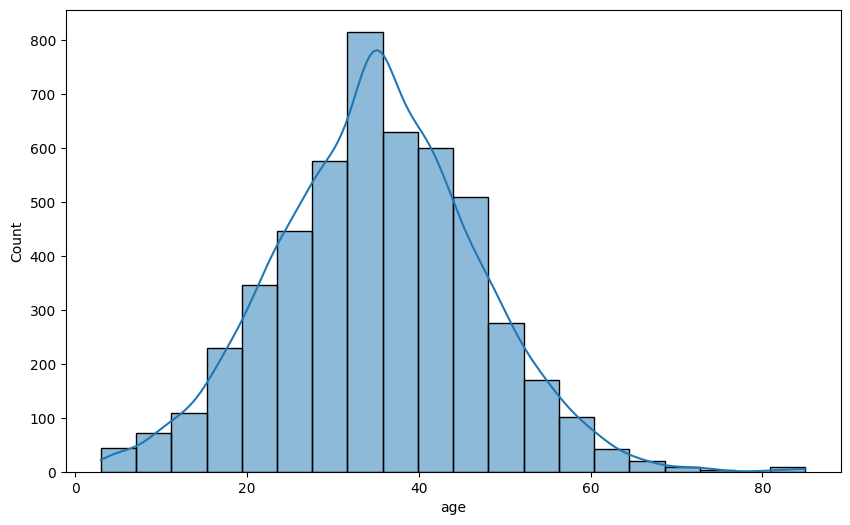

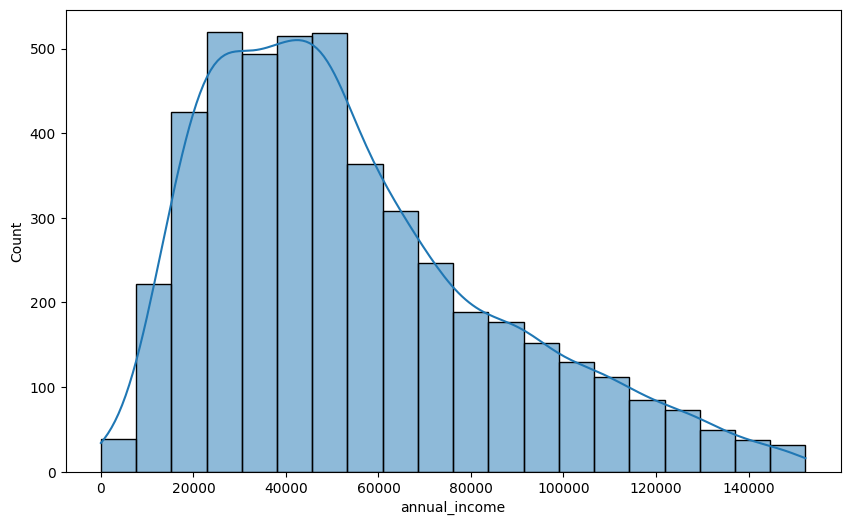

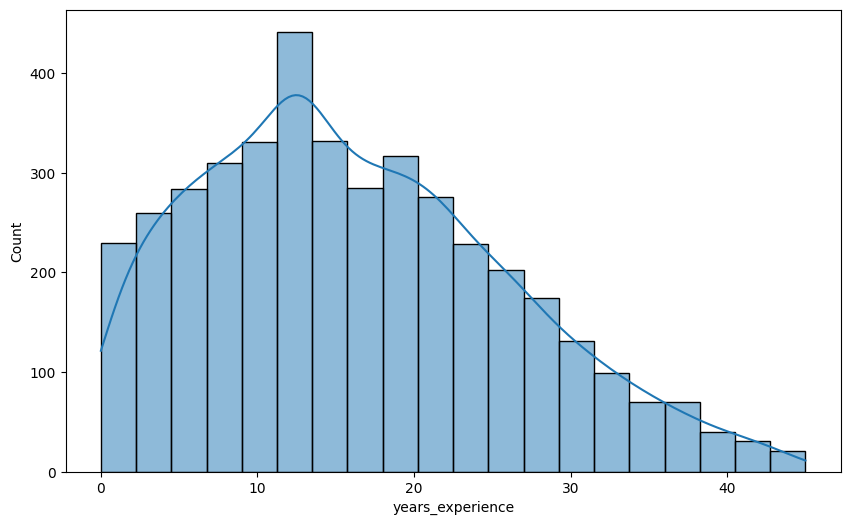

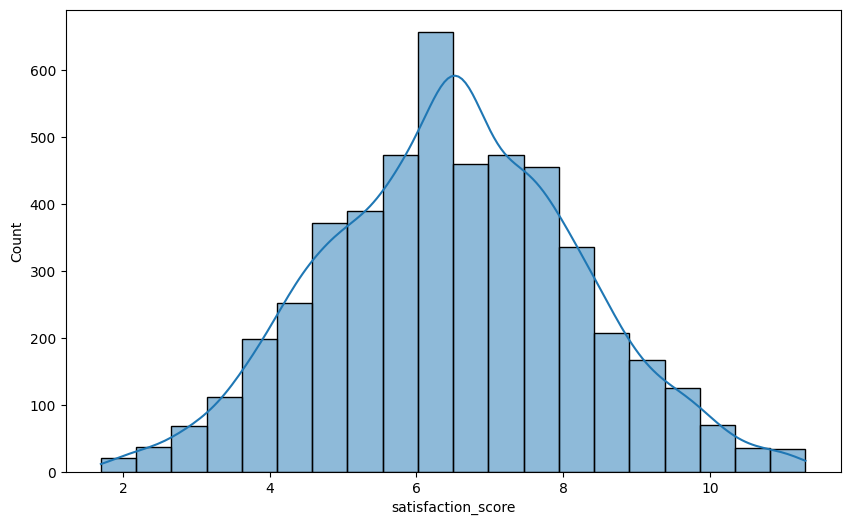

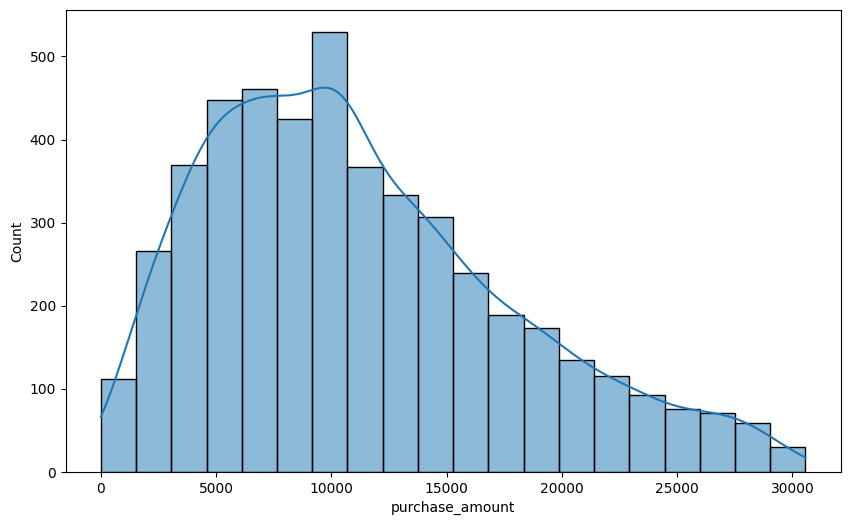

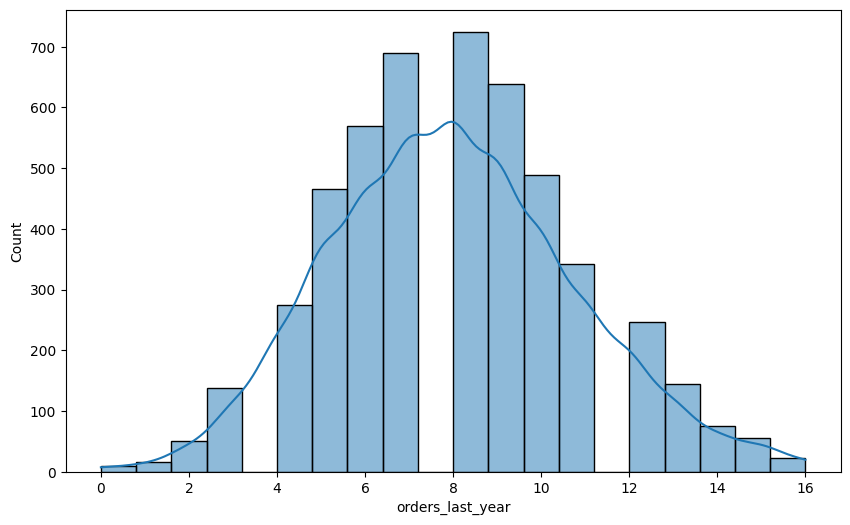

In [57]:
for col in num_cols:
  plt.figure(figsize=(10,6))
  sns.histplot(data[col],kde=True, bins=20)

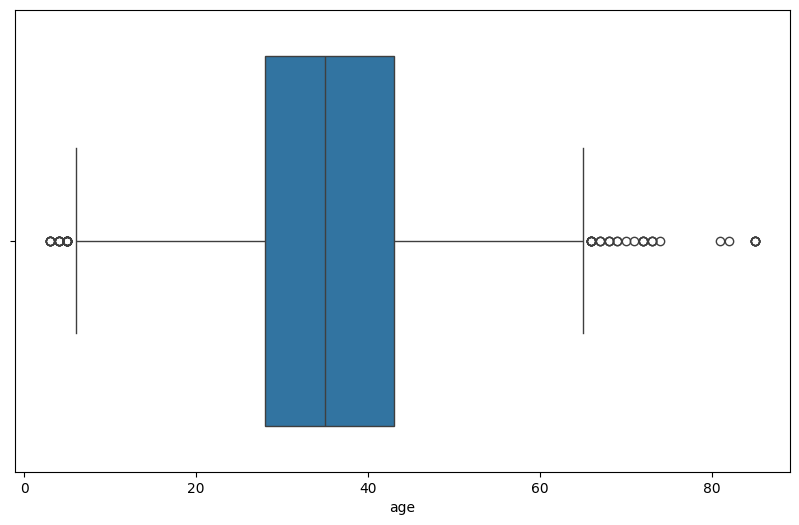

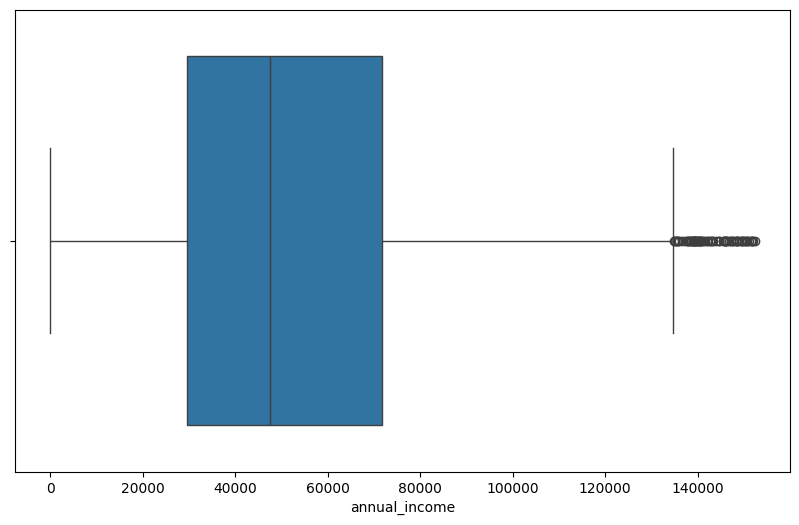

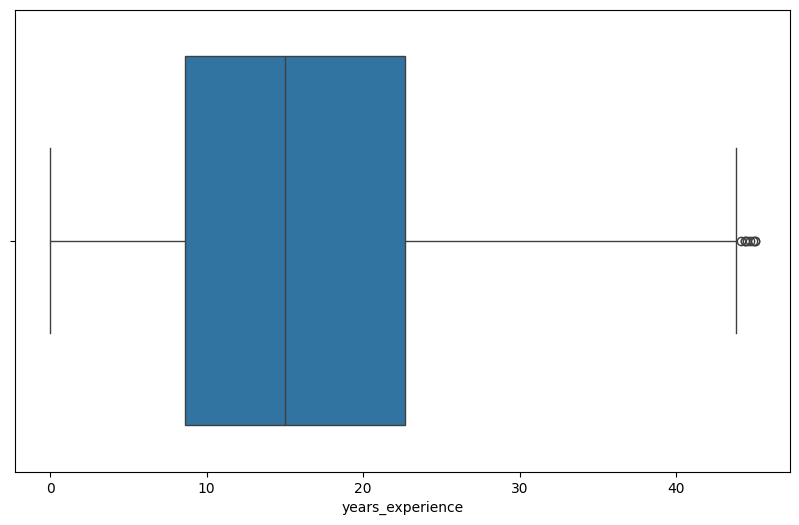

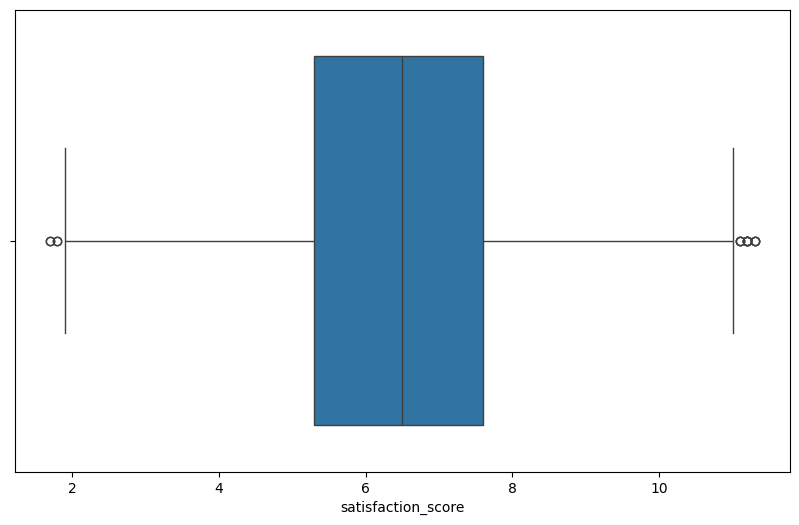

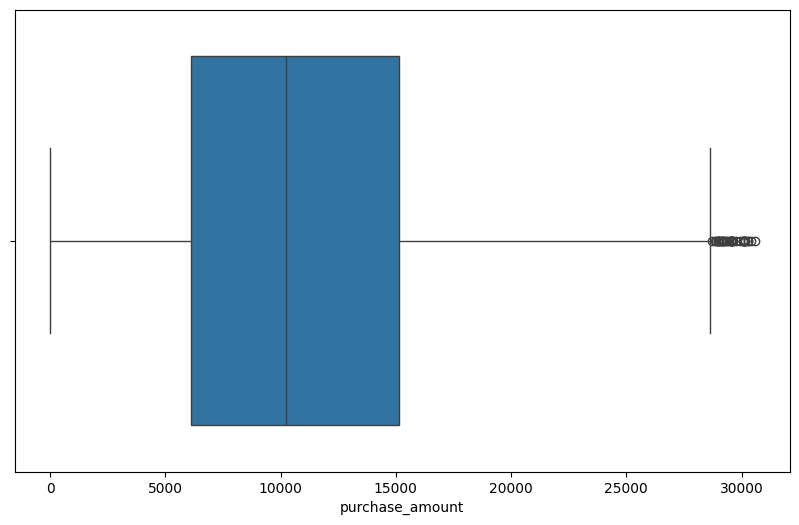

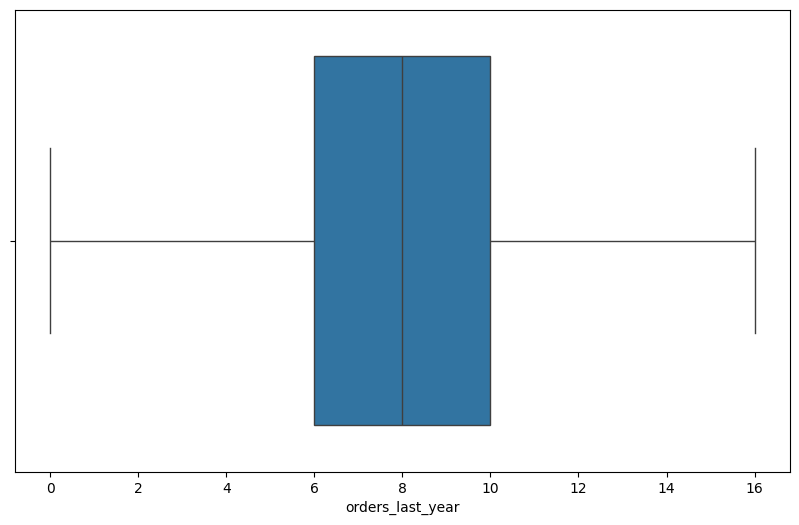

In [59]:
for col in num_cols:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=data[col])

In [61]:
data.describe()

,age,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year
count,5000.000000,4683.000000,4135.000000,4941.000000,4792.000000,4953.000000
mean,35.218600,54120.546472,16.209940,6.490771,11229.491565,7.976984
std,11.724483,31453.032156,9.836635,1.724906,6593.400229,2.781320
min,3.000000,0.000000,-0.000000,1.700000,0.000000,0.000000
25%,28.000000,29554.530000,8.600000,5.300000,6127.147500,6.000000
50%,35.000000,47637.960000,15.000000,6.500000,10247.545000,8.000000
75%,43.000000,71662.225000,22.700000,7.600000,15150.002500,10.000000
max,85.000000,152297.490000,45.000000,11.300000,30565.460000,16.000000


In [62]:
data.head()

,customer_id,age,gender,city,education,employment_status,annual_income,years_experience,satisfaction_score,purchase_amount,orders_last_year,join_date,phone,email,churned
0,CUST_00001,41.0,female,kathmandu,see,self-employed,104902.90,11.6,2.9,14158.95,7.0,2018-01-01,9897927116,customer1@example.com,no
1,CUST_00002,33.0,female,biratnagar,high school,self employed,29779.82,13.2,5.8,11691.22,8.0,2018-01-02,9864481067,customer2@example.com,no
2,CUST_00003,43.0,male,hetauda,master,employed,0.00,24.2,3.6,6126.37,5.0,2018-01-03,9855339410,customer3@example.com,no
3,CUST_00004,53.0,male,bhaktapur,phd,unemployed,108698.43,27.2,7.2,6144.84,4.0,2018-01-04,9876128481,customer4@example.com,yes
4,CUST_00005,32.0,male,chitwan,master,employed,94495.41,4.9,3.5,11211.18,6.0,2018-01-05,9847472648,customer5@example.com,no


In [ ]:

for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=data,
        x=col,
        y='insurance_charge'
    )
    plt.title(f'{col} vs Insurance Charge')
    plt.show()